In [1]:
import torch
torch.cuda.is_available()

True

In [2]:
11 + 2

13

In [3]:
import numpy as np
import random
import math
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
class SlotArm():
    def __init__(self, p):
        self.p = p

    def draw(self):
        return 1 if self.p > random.random()  else 0

In [5]:
class EpsilonGreedyAgent():
    def __init__(self, epsilon):
        self.epsilon = epsilon
    def initialize(self, n_arms):
        self.n = np.zeros(n_arms) # 各アームの試行回数
        self.v = np.zeros(n_arms) # 各アームの価値
    
    def select_arm(self):
        if self.epsilon > random.random():
            # ランダムにアームを選択
            return np.random.randint(0, len(self.v))
        else:
            # 価値が最大のアームを選択
            return np.argmax(self.v)
    
    def update(self, chosen_arm, reward, t):
        # 選択したアームの試行回数を更新
        self.n[chosen_arm] += 1

        # 選択したアームの価値を更新
        n= self.n[chosen_arm]
        v = self.v[chosen_arm]
        
        self.v[chosen_arm] = ((n-1)/ float(n)) * v + (1/float(n)) * reward

    # 文字列情報の取得
    def label(self):
        return "Epsilon-Greedy(" + str(self.epsilon) + ")" 

In [6]:
class UCB1():
    def initialize(self, n_arms):
        self.n = np.zeros(n_arms) # 各アームの試行回数
        self.w = np.zeros(n_arms) # 各アームの成功回数
        self.v = np.zeros(n_arms) # 各アームの価値
    def select_arm(self):
        # nがすべて1以上になるようにアームを選択
        for arm in range(len(self.n)):
            if self.n[arm] == 0:
                return arm
        # 価値が高いアームを選択
        return np.argmax(self.v)
    # アルゴリズムのパラメータを更新
    def update(self, chosen_arm, reward, t):
        # 選択したアームの試行回数を更新
        self.n[chosen_arm] += 1

        # 成功したときは選択したアームの成功回数を加算
        if reward == 1:
            self.w[chosen_arm] += 1

        # 試行回数が0のアームが存在するときは価値を更新しない
        for i in range(len(self.n)):
            if self.n[i] == 0:
                return
            
        # 各アームの価値を更新
        for i in range(len(self.n)):
            self.v[i] = (self.w[i] / self.n[i]) + math.sqrt((2 * math.log(t)) / self.n[i])

    def label(self):
        return "UCB1"

In [14]:
def play(algo, arms, num_sims, num_time):
    # 履歴の準備
    times = np.zeros(num_sims * num_time) # ゲーム回数の何回目か
    rewards = np.zeros(num_sims * num_time) # 各ステップで得られた報酬

    # シミュレーション回数分ループ
    for sim in range(num_sims):
        algo.initialize(len(arms))
        # 各時間ステップ分ループ
        for t in range(num_time):
            index = sim * num_time + t

            # 履歴の計算
            times[index] = t + 1
            chosen_arm = algo.select_arm()
            reward = arms[chosen_arm].draw()
            rewards[index] = reward
            algo.update(chosen_arm, reward, t + 1)
    return [times, rewards]

times
1.0    0.347
2.0    0.346
3.0    0.332
4.0    0.351
5.0    0.370
Name: rewards, dtype: float64
times
1.0    0.311
2.0    0.499
3.0    0.898
4.0    0.550
5.0    0.780
Name: rewards, dtype: float64


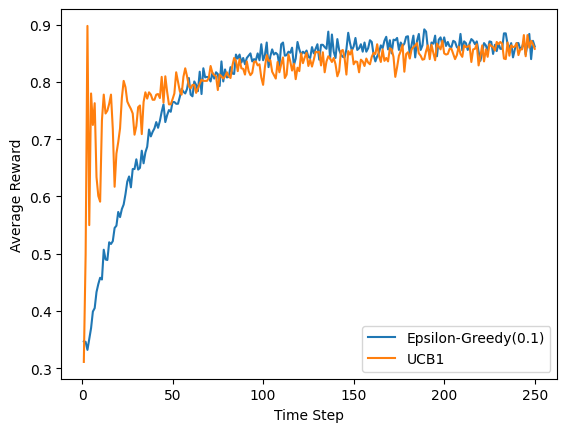

In [15]:
# 
arms = (SlotArm(0.3), SlotArm(0.5), SlotArm(0.9))

algos = [EpsilonGreedyAgent(0.1), UCB1()]

for algo in algos:
    # シミュレーションの実行
    results = play(algo, arms, num_sims=1000, num_time=250)

    # グラフの表示
    df = pd.DataFrame({"times": results[0], "rewards": results[1]})
    mean = df["rewards"].groupby(df["times"]).mean()
    print(mean.head())
    plt.plot(mean, label=algo.label())

plt.xlabel("Time Step")
plt.ylabel("Average Reward")
plt.legend()